# Explore here

In [29]:
# Your code here
#Dividir la carpeta train en una carpeta de dogs y una de cats
import os
import shutil

def split_train_folder(train_folder):
    dogs_folder = os.path.join(train_folder, 'dogs')
    cats_folder = os.path.join(train_folder, 'cats')

    # Crear las carpetas de dogs y cats si no existen
    os.makedirs(dogs_folder, exist_ok=True)
    os.makedirs(cats_folder, exist_ok=True)

    # Iterar sobre los archivos en la carpeta train
    for filename in os.listdir(train_folder):
        #evita la carpeta de dogs y cats
        if filename in ['dogs', 'cats']:
            continue
        if filename.startswith('dog'):
            shutil.move(os.path.join(train_folder, filename), os.path.join(dogs_folder, filename))
        elif filename.startswith('cat'):
            shutil.move(os.path.join(train_folder, filename), os.path.join(cats_folder, filename))

#ejemplo de uso
train_folder = '/Users/mariafiguera/ClasficadordeImagenesMGF/data/raw/dogs-vs-cats/train'            
split_train_folder(train_folder)

In [30]:
#genera una caropeta de test seleccionando aleatoriamente 1250 imagenes de cada clase
import random

def create_test_folder(train_folder, test_folder, num_samples=1250):
    dogs_folder = os.path.join(train_folder, 'dogs')
    cats_folder = os.path.join(train_folder, 'cats')

    # Crear las subcarpetas de dogs y cats dentro de la carpeta de test
    test_dogs_folder = os.path.join(test_folder, 'dogs')
    test_cats_folder = os.path.join(test_folder, 'cats')

    os.makedirs(test_dogs_folder, exist_ok=True)
    os.makedirs(test_cats_folder, exist_ok=True)

    # Obtener las listas de archivos de dogs y cats
    dog_files = [f for f in os.listdir(dogs_folder) if f.endswith('.jpg')]
    cat_files = [f for f in os.listdir(cats_folder) if f.endswith('.jpg')]

    # Seleccionar aleatoriamente num_samples archivos de cada clase
    selected_dogs = random.sample(dog_files, num_samples)
    selected_cats = random.sample(cat_files, num_samples)

    # Mover los archivos seleccionados a la carpeta de test
    for filename in selected_dogs:
        shutil.move(os.path.join(dogs_folder, filename), os.path.join(test_folder, filename))
    for filename in selected_cats:
        shutil.move(os.path.join(cats_folder, filename), os.path.join(test_folder, filename))

 #ejemplo de uso
test_folder = '/Users/mariafiguera/ClasficadordeImagenesMGF/data/raw/dogs-vs-cats/test'            
create_test_folder(train_folder, test_folder)       

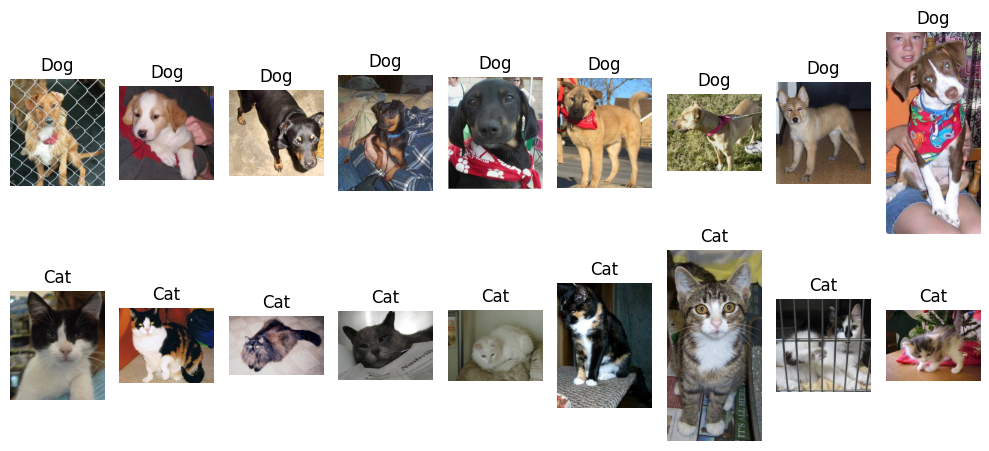

In [31]:
#actualizar 9 fotos de cada clase
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
def visualize_samples(train_folder, num_samples=9):
    dogs_folder = os.path.join(train_folder, 'dogs')
    cats_folder = os.path.join(train_folder, 'cats')

    # Obtener las listas de archivos de dogs y cats
    dog_files = [f for f in os.listdir(dogs_folder) if f.endswith('.jpg')]
    cat_files = [f for f in os.listdir(cats_folder) if f.endswith('.jpg')]

    # Seleccionar aleatoriamente num_samples archivos de cada clase
    selected_dogs = random.sample(dog_files, num_samples)
    selected_cats = random.sample(cat_files, num_samples)

    # Visualizar las imágenes seleccionadas
    plt.figure(figsize=(10, 5))
    
    for i, filename in enumerate(selected_dogs):
        img = mpimg.imread(os.path.join(dogs_folder, filename))
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.title('Dog')
        plt.axis('off')

    for i, filename in enumerate(selected_cats):
        img = mpimg.imread(os.path.join(cats_folder, filename))
        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(img)
        plt.title('Cat')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

#ejemplo de uso
visualize_samples(train_folder)

In [32]:
import os
import shutil

def organize_test_folder(test_root):
    # 1. Definimos las subcarpetas dentro de TEST
    test_dogs_dir = os.path.join(test_root, 'dogs')
    test_cats_dir = os.path.join(test_root, 'cats')

    # 2. Las creamos si no existen
    os.makedirs(test_dogs_dir, exist_ok=True)
    os.makedirs(test_cats_dir, exist_ok=True)

    # 3. Movemos solo los archivos que están sueltos en TEST
    for filename in os.listdir(test_root):
        # Ignoramos las carpetas que acabamos de crear
        if filename in ['dogs', 'cats']:
            continue
        
        # Solo procesamos archivos .jpg
        if filename.endswith('.jpg'):
            src_path = os.path.join(test_root, filename)
            
            if filename.startswith('dog'):
                shutil.move(src_path, os.path.join(test_dogs_dir, filename))
            elif filename.startswith('cat'):
                shutil.move(src_path, os.path.join(test_cats_dir, filename))

    print("¡Carpeta TEST organizada correctamente!")

# EJECUCIÓN:
ruta_test = '/Users/mariafiguera/ClasficadordeImagenesMGF/data/raw/dogs-vs-cats/test'
organize_test_folder(ruta_test)

¡Carpeta TEST organizada correctamente!


In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def load_data(ruta, img_size=(200, 200), batch_size=32):
    # 1. Definimos un ÚNICO generador que se encargará de dividir los datos
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.1 # <-- Esto divide tus 25,000 fotos
    )

    # 2. Cargamos el grupo de Entrenamiento (90% = 22,500 imágenes)
    train_generator = datagen.flow_from_directory(
        ruta,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='training' # <-- Toma la parte mayoritaria
    )

    # 3. Cargamos el grupo de Validación (10% = 2,500 imágenes)
    test_generator = datagen.flow_from_directory(
        ruta,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        subset='validation' # <-- Toma la parte pequeña
    )

    return train_generator, test_generator

# Tu ruta en la Mac
ruta_que_funciona = '/Users/mariafiguera/ClasficadordeImagenesMGF/data/raw/dogs-vs-cats/train'

# Llamamos a la función
train_generator, test_generator = load_data(ruta_que_funciona)

Found 13500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [37]:
#hacer un modelo de CNN con Keras usando VGG16 como base
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

#cargar el modelo VGG16 sin la parte de superiror (clasificación)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

#crear un modelo secuencial y agregar el modelo base
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))   

#Congelar las capas del modelo base para que no se entrenen
base_model.trainable = False

#compilar el modelo
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

#Resumen del modelo
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 4,719,105 (18.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [38]:
!pip install scipy

In [39]:
#haz predicciones con el modelo pero entrenalo con gpu
import tensorflow as tf

#Check ig gpu is available
if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Training on GPU.")
else:
    print("GPU is not available. Training on CPU.")

#Entrenar el modelo
history = model.fit(
    train_generator, 
    steps_per_epoch=train_generator.samples // train_generator.batch_size, 
    epochs=10, 
    validation_data=test_generator, 
    validation_steps=test_generator.samples // test_generator.batch_size
    )
   
#evaluar el modleo
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f'Test accuracy: {test_acc:.2f}')



GPU is not available. Training on CPU.
Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 1093s 3s/step - accuracy: 0.8050 - loss: 0.4375 - val_accuracy: 0.8655 - val_loss: 0.3268
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 121s 282ms/step - accuracy: 0.8125 - loss: 0.4624 - val_accuracy: 0.8723 - val_loss: 0.3236
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 1369s 3s/step - accuracy: 0.8334 - loss: 0.3638 - val_accuracy: 0.8519 - val_loss: 0.3192
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 138s 321ms/step - accuracy: 0.7812 - loss: 0.3387 - val_accuracy: 0.8478 - val_loss: 0.3351
Epoch 5/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 1270s 3s/step - accuracy: 0.8540 - loss: 0.3277 - val_accuracy: 0.8641 - val_loss: 0.2897
Epoch 6/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 112s 262ms/step - accuracy: 0.8750 - loss: 0.2883 - val_accuracy: 0.8648 - val_loss: 0.2950
Epoch 7/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 1095s 3s/step - accuracy: 0.8499 - loss: 0.3324 - val_accuracy: 0.8682 - val_loss: 0.2870
Epoch 8/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 109s 

In [41]:
#guardar el modelo
model.save('/Users/mariafiguera/ClasficadordeImagenesMGF/models/dogs_vs_cats_vgg16.keras')


In [44]:
#rescatar el modelo y evaluar de nuevo
from tensorflow.keras.models import load_model

#cargar el modelo guardado
model = load_model('/Users/mariafiguera/ClasficadordeImagenesMGF/models/dogs_vs_cats_vgg16.keras')

#Evaluar el modelo carganmdo en el conjunto de test
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f'Test accuracy after loading model: {test_acc:.2f}')

46/46 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8662 - loss: 0.2855
Test accuracy after loading model: 0.87


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
La imagen es un gato


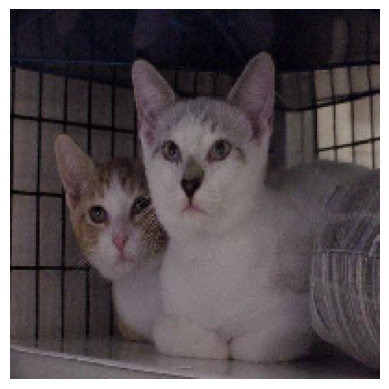

In [48]:
#rescata una imagen de test y haz una predicción
import numpy as np
from tensorflow.keras.preprocessing import image

#carga una imagen de prueba
img_path = '/Users/mariafiguera/ClasficadordeImagenesMGF/data/raw/dogs-vs-cats/test/cats/cat.81.jpg' # <-- Cambia esta ruta por la de una imagen que quieras probar
img = image.load_img(img_path, target_size=(200, 200))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0) # Agrega una dimensión para el batch
#hacer la prediccion
prediction = model.predict(img_array)
if prediction[0] > 0.5:
    print('La imagen es un perro')
else:
    print('La imagen es un gato')

#muestra la imagen de prueba
plt.imshow(img)
plt.axis('off')
plt.show() 


### 💡 Conclusión y Resultados
La implementación de Transfer Learning con VGG16 demostró ser una estrategia altamente eficiente. Tras cargar el modelo entrenado, se obtuvo una **precisión de prueba (Test Accuracy) del 87%**, lo cual es un resultado sobresaliente para un clasificador de este tipo.

El uso de pesos pre-entrenados permitió alcanzar este desempeño sin necesidad de hardware masivo o tiempos de entrenamiento excesivos. Este proyecto refuerza mi capacidad para gestionar flujos de trabajo completos de Machine Learning, desde el preprocesamiento hasta la validación de resultados con métricas reales.